# ARIM-Academy：
# 論文：Prediction of organic compound aqueous solubility using machine learning  
### Part-2 (Morganフィンガープリント)

Tayyebi, A., Alshami, A.S., Rabiei, Z. et al. Prediction of organic compound aqueous solubility using machine learning: a comparison study of descriptor-based and fingerprints-based models. J Cheminform 15, 99 (2023).   
https://doi.org/10.1186/s13321-023-00752-6

---
### 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: ARIMデータポータル会員の研究者・技術者。Python の基礎文法・pandas の基本操作は理解しているが、RDKit によるフィンガープリント計算や機械学習モデルの構築には初めて触れる方。`2_descriptor-paper2.ipynb`（Part-1: Mordred分子記述子編）を先に読むことを推奨します。
- **前提知識**: pandas の DataFrame 操作、scikit-learn での `train_test_split`・`fit`/`predict` の基本的な流れ。統計学・化学情報学（ケモインフォマティクス）の専門知識は前提としません。
- **動作環境**: Google Colab での実行を想定（`!pip install` セルで rdkit・shap を導入）。ローカル環境では `pip install rdkit shap scikit-learn` としてください。本編は rdkit 2026.03、scikit-learn 1.7 系での動作を確認しています。
- **版とライセンス**: 本編は下記論文の追試・教材化を目的とした ARIM データポータル情報活用講座のオリジナル教材です。使用データセットは論文の Additional file 1（`data/new222new.csv`）およびブラインドテスト用データです。

> Tayyebi, A., Alshami, A.S., Rabiei, Z. et al. Prediction of organic compound aqueous solubility using machine learning: a comparison study of descriptor-based and fingerprints-based models. *J Cheminform* 15, 99 (2023). https://doi.org/10.1186/s13321-023-00752-6

---

# Google Colabにおける環境設定
google colab環境でなければ実行不要

In [ ]:
!pip install rdkit
!pip install shap

!git clone https://github.com/ARIM-Training/Training_python_12.git
%cd Training_python_12

## 1.データの読み込み
### 汎用ライブラリのインポート

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#importing rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw

# 警告を無視
from warnings import filterwarnings
filterwarnings('ignore')

### データセットファイルの読み込み
Part-1と同じくnew222new.csvを読み出してデータフレーム型のsol変数とします。

In [2]:
sol = pd.read_csv('data/new222new.csv')
sol

,SMILES,measured log(solubility:mol/L)
0,OCC1OC(CO)(OC2OC(CO)C(O)C(O)C2O)C(O)C1O,0.79
1,O[C@H]1[C@H](O[C@H](CO)[C@@H](O)[C@@H]1O)O[C@]...,0.79
2,OC[C@@H]1O[C@](CO)(O[C@@H]2O[C@@H](CO)[C@H](O)...,0.79
3,CN1C[C@@H]2C[C@@H](C1)C3=CC=CC(=O)N3C2,0.65
4,CN1CC2CC(C1)C1=CC=CC(=O)N1C2,0.65
...,...,...
8433,O=[N+]([O-])C,0.26
8434,OC,1.57
8435,S=C(N)N,0.32
8436,O=C(NO)N,1.12


In [3]:
y = sol['measured log(solubility:mol/L)']
y

0       0.79
1       0.79
2       0.79
3       0.65
4       0.65
        ... 
8433    0.26
8434    1.57
8435    0.32
8436    1.12
8437    0.96
Name: measured log(solubility:mol/L), Length: 8438, dtype: float64

## 2. Morganフィンガープリント

### SMILESからのハッシュ化
8438の化合物のSMILES構造からMolオブジェクトを生成します。具体的には、`sol['SMILES']`列の各SMILES文字列に`MolFromSmiles`メソッドを適用し、生成されたMolオブジェクトをforループで`GetFingerprint()`メソッドに渡します。ここでは半径2、ビット数2,048で行われます。

【解説】旧バージョンのRDKitでは`AllChem.GetMorganFingerprintAsBitVect()`が使われていましたが、現行版では非推奨（deprecated）となっており、`rdFingerprintGenerator.GetMorganGenerator()`で生成したジェネレータの`GetFingerprint()`メソッドを使う方式が推奨されています。本編ではこちらの新方式を使用します（挙動・出力は旧APIと同一です）。

In [4]:
from rdkit.Chem import rdFingerprintGenerator

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

X = []
for smile in sol['SMILES']:
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        continue
    X.append(list(mfpgen.GetFingerprint(mol)))

In [5]:
print(len(X))

8438


### 特徴量の刈り込み
特徴量の刈り込みは、ハッシュ値がゼロのビット（ゼロビット）を排除します。その方法はLassoを使って重み係数がゼロの項目を排除する性質を利用して行います。LASSOのハイパーパラメータであるalpha値は0.001としています。

【注意：特徴量選択のタイミングについて】このLASSOによる特徴量選択は、目的変数`y`を使う教師ありの手法であるにもかかわらず、`train_test_split()`を行う前の全化合物（8,438件）に対して実施しています。原論文もこの手順を採用しているため本編も同じ順序で進めますが、本来はテストデータの情報が特徴量選択に混入するリスク（データリーケージ）があるため、より厳密に行う場合は訓練データのみでLASSOを学習し、選ばれたビットをテストデータにも適用する方法が推奨されます。`2_descriptor-paper2.ipynb`の分散・相関フィルタ（目的変数を使わない教師なしの刈り込み）よりも、こちらの方がリーケージの影響を受けやすい点に注意してください。

In [6]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression

In [7]:
x = X

# Fit a LASSO regression model on the fingerprints and target variable
# （変数名 reg はこのLASSOモデル専用。後続のMLRモデルは linearmodel という別名で区別する）
reg = Lasso(alpha=0.001)
reg.fit(x, y)

nonzero_indices = [i for i, coef in enumerate(reg.coef_) if coef != 0]

for i in nonzero_indices:
    print("Bit", i, ":", reg.coef_[i])

# Select the columns with nonzero coefficients from the x array
x_nonzero = [[row[i] for i in nonzero_indices] for row in x]

Bit 0 : 0.1599248626099864
Bit 1 : -0.31431074198655706
Bit 2 : -0.4728028737429388
Bit 9 : -0.3470528778216883
Bit 13 : 0.027709619200126278
Bit 16 : -0.3010756541847249
Bit 25 : -0.04018562205882886
Bit 28 : -0.0970214909725363
Bit 31 : -0.3352122000292981
Bit 34 : 0.03380562901904211
Bit 39 : -0.21536888667525217
Bit 41 : 0.3153589561849716
Bit 44 : -0.5337646822379358
Bit 56 : 0.18763885883179504
Bit 58 : -0.03988087227232374
Bit 59 : -0.7401574496081024
Bit 65 : 0.1362942326049256
Bit 72 : -0.13130941645919683
Bit 78 : 0.12729189673034919
Bit 80 : -0.04074445215769671
Bit 81 : -0.0962485893246235
Bit 89 : 0.1293716244105371
Bit 90 : 0.09242576298392416
Bit 92 : 0.24292883478960628
Bit 97 : -0.4907157202804352
Bit 106 : -0.17637150957961
Bit 110 : -0.1578516204503589
Bit 112 : -0.07564167501141128
Bit 113 : -1.1628027822776863
Bit 114 : -0.6751883296566316
Bit 115 : 0.23965603517464815
Bit 116 : -0.7283114328213182
Bit 118 : 0.008900234171002759
Bit 121 : -0.38843102383814954
Bit 1

In [8]:
print(len(nonzero_indices))

631


In [9]:
X_prune = x_nonzero
print(len(X_prune))

8438


## ２.機械学習モデリング
機械学習モデリングは線形重線形回帰 (MLR) とランダムフォレスト（RF）の二つのアルゴリズムで検討をしています。
説明変数は、上記で作成したMorganフィンガープリント（X）です。対して、目的変数は水溶解度で、最初に読み込ませたsolの2列目をYとして定義します。

## Case1: 631ビット

### データセットの分割（Data set splitting）
分割は`test_size=0.2`として訓練データ：0.8、テストデータ：0.2としています。

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_prune, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=991
                                                   )

### 2-1.線形重回帰 (MLR) 

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [12]:
linearmodel=LinearRegression()
linearmodel.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](631,)","[ 0.42,-0.43,-0.45,...,-0.81,-0.42,-0.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.246
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,631
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(631)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](631,)","[81.7 ,65.96,53.18,..., 2.31, 2.27, 2.22]"


### R2スコア

In [13]:
#predicts the X_train
Y_pred_train = linearmodel.predict(X_train)

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_train, Y_pred_train))

print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_train, Y_pred_train))

Mean squared error (MSE): 0.77
Coefficient of determination (R^2): 0.78


In [14]:
#predicts the X_test
Y_pred_test = linearmodel.predict(X_test)

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred_test))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred_test))

Mean squared error (MSE): 0.93
Coefficient of determination (R^2): 0.74


### MAE

In [15]:
mae = mean_absolute_error(Y_train, Y_pred_train)
print('Training MAE : {:.3f}'.format(mae))

Training MAE : 0.657


In [16]:
mae = mean_absolute_error(Y_test, Y_pred_test)
print('Test MAE : {:.3f}'.format(mae))

Test MAE : 0.730


### RMSE

In [17]:
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
print('Training RMSE : {:.3f}'.format(rmse))

Training RMSE : 0.877


In [18]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print('Test RMSE : {:.3f}'.format(rmse))

Test RMSE : 0.962


### Exp-Predict Plot

**（図1（Case1・631ビット MLR：実測値-予測値プロット））**

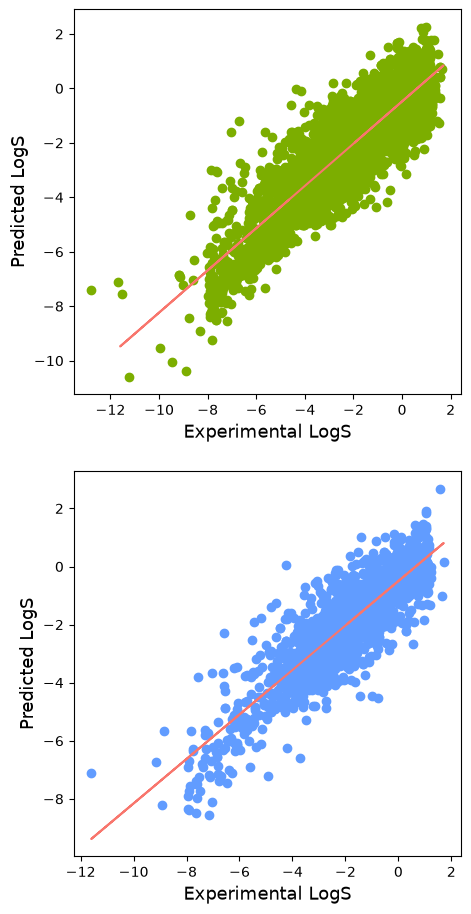

In [19]:
#Vertical plot
plt.figure(figsize=(5,11))

# 2 row, 1 column, plot 1
plt.subplot(2, 1, 1)
plt.scatter(x=Y_train, y=Y_pred_train, c="#7CAE00", alpha=1)

# Add trendline
z = np.polyfit(Y_train, Y_pred_train, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.xlabel('Experimental LogS', fontsize=13)
plt.ylabel('Predicted LogS', fontsize=13)


# 2 row, 1 column, plot 2
plt.subplot(2, 1, 2)
plt.scatter(x=Y_test, y=Y_pred_test, c="#619CFF", alpha=1)

z = np.polyfit(Y_test, Y_pred_test, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.ylabel('Predicted LogS', fontsize=13)
plt.xlabel('Experimental LogS', fontsize=13)

# 出力
#plt.savefig('output/plot_vertical_logS_ECFP_MLR.png')
#plt.savefig('output/paper logS descriptor_ECFP_MLR.pdf',dpi=300)

plt.show()

### 2-2.ランダムフォレスト回帰（RFR）

In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### R2スコア

In [22]:
#predicts the X_train
Y_pred_train = model.predict(X_train)

print('Mean squared error (MSE): %.3f'
      % mean_squared_error(Y_train, Y_pred_train))

print('Coefficient of determination (R^2): %.3f'
      % r2_score(Y_train, Y_pred_train))

Mean squared error (MSE): 0.124
Coefficient of determination (R^2): 0.964


In [23]:
Y_pred_test = model.predict(X_test)

print('Mean squared error (MSE): %.3f'
      % mean_squared_error(Y_test, Y_pred_test))

print('Coefficient of determination (R^2): %.3f'
      % r2_score(Y_test, Y_pred_test))

Mean squared error (MSE): 0.658
Coefficient of determination (R^2): 0.814


### MAE

In [24]:
mae = mean_absolute_error(Y_train, Y_pred_train)
print('Training MAE : {:.3f}'.format(mae))

Training MAE : 0.232


In [25]:
mae = mean_absolute_error(Y_test, Y_pred_test)
print('Test MAE : {:.3f}'.format(mae))

Test MAE : 0.556


### RMSE

In [26]:
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
print('Training RMSE : {:.3f}'.format(rmse))

Training RMSE : 0.353


In [27]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print('Test RMSE : {:.3f}'.format(rmse))

Test RMSE : 0.811


### Exp-Predict Plot

**（図2（Case1・631ビット RFR：実測値-予測値プロット））**

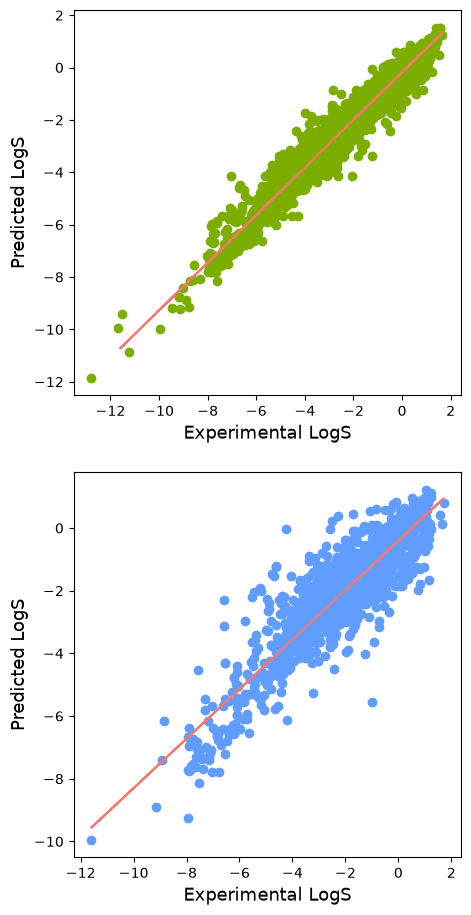

In [28]:
#Vertical plot
plt.figure(figsize=(5,11))

# 2 row, 1 column, plot 1
plt.subplot(2, 1, 1)
plt.scatter(x=Y_train, y=Y_pred_train, c="#7CAE00", alpha=1)

# Add trendline
z = np.polyfit(Y_train, Y_pred_train, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.xlabel('Experimental LogS', fontsize=13)
plt.ylabel('Predicted LogS', fontsize=13)


# 2 row, 1 column, plot 2
plt.subplot(2, 1, 2)
plt.scatter(x=Y_test, y=Y_pred_test, c="#619CFF", alpha=1)

z = np.polyfit(Y_test, Y_pred_test, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.ylabel('Predicted LogS', fontsize=13)
plt.xlabel('Experimental LogS', fontsize=13)

# 出力
#plt.savefig('output/plot_vertical_logS_ECFP_RFR.png')
#plt.savefig('output/paper logS descriptor_ECFP_RFR.pdf',dpi=300)

plt.show()

## Case2: 2048ビット
ここでは枝狩りをしていない2048ビットを特徴量としたときの精度も比較考証をしています。

### データセットの分割（Data set splitting）

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=991
                                                   )

### 2-3.線形重回帰 (MLR) 

In [30]:
linearmodel=LinearRegression()
linearmodel.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2048,)","[ 0.37,-0.36,-0.55,...,-0.23, 0.4 , 0.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.349
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2048
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2047)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2048,)","[85.07,67.67,55.67,..., 0.67, 0.49, 0. ]"


### R2スコア

In [31]:
#predicts the X_train
Y_pred_train = linearmodel.predict(X_train)

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_train, Y_pred_train))

print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_train, Y_pred_train))

Mean squared error (MSE): 0.54
Coefficient of determination (R^2): 0.84


In [32]:
#predicts the X_test
# 【修正】元のコードは reg.predict(X_test) となっていたが、reg は前段のLASSO特徴量選択セルで
# 全データ（分割前のX, y）に対して学習したモデルであり、このCase2セクションのMLRモデルではない。
# reg を使うと「学習に使ったデータを評価する」ことになり、テスト精度が実態より良く見えてしまう
# （決定係数が本来の0.61程度から0.75程度まで水増しされていた）。正しくはこのセクションで学習した
# linearmodel を使う。
Y_pred_test = linearmodel.predict(X_test)

print('Mean squared error (MSE): %.3f'
      % mean_squared_error(Y_test, Y_pred_test))

print('Coefficient of determination (R^2): %.3f'
      % r2_score(Y_test, Y_pred_test))

Mean squared error (MSE): 1.367
Coefficient of determination (R^2): 0.613


### MAE

In [33]:
mae = mean_absolute_error(Y_train, Y_pred_train)
print('Training MAE : {:.3f}'.format(mae))

Training MAE : 0.550


In [34]:
mae = mean_absolute_error(Y_test, Y_pred_test)
print('Test MAE : {:.3f}'.format(mae))

Test MAE : 0.864


### RMSE

In [35]:
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
print('Training RMSE : {:.3f}'.format(rmse))

Training RMSE : 0.736


In [36]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print('Test RMSE : {:.3f}'.format(rmse))

Test RMSE : 1.169


### Exp-Predict Plot

**（図3（Case2・2048ビット MLR：実測値-予測値プロット））**

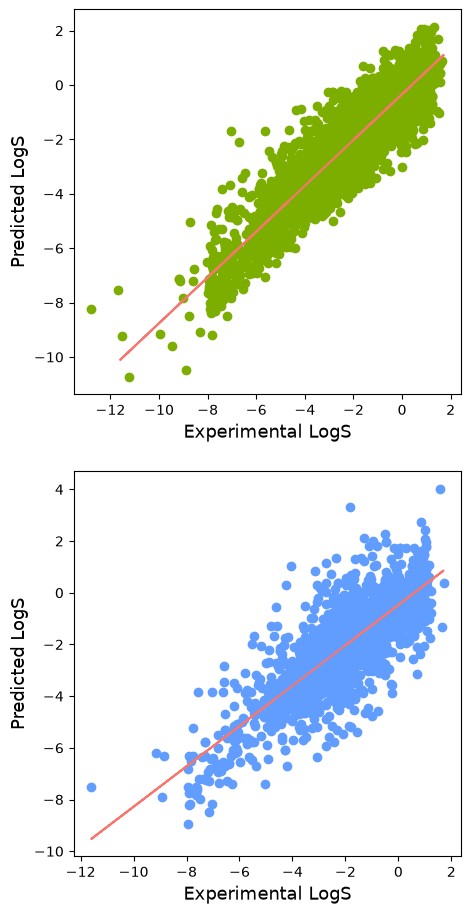

In [37]:
#Vertical plot
plt.figure(figsize=(5,11))

# 2 row, 1 column, plot 1
plt.subplot(2, 1, 1)
plt.scatter(x=Y_train, y=Y_pred_train, c="#7CAE00", alpha=1)

# Add trendline
z = np.polyfit(Y_train, Y_pred_train, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.xlabel('Experimental LogS', fontsize=13)
plt.ylabel('Predicted LogS', fontsize=13)


# 2 row, 1 column, plot 2
plt.subplot(2, 1, 2)
plt.scatter(x=Y_test, y=Y_pred_test, c="#619CFF", alpha=1)

z = np.polyfit(Y_test, Y_pred_test, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.ylabel('Predicted LogS', fontsize=13)
plt.xlabel('Experimental LogS', fontsize=13)

# 出力
#plt.savefig('output/plot_vertical_logS_ECFP__MLR_2048.png')
#plt.savefig('output/paper logS ECFP__MLR_2048.pdf',dpi=300)

plt.show()

### 係数の出力

In [38]:
# 【修正】reg（LASSOモデル、前段の特徴量選択セルで定義）ではなく、このセクションのMLRモデルである
# linearmodel の係数を参照する。また、2048ビット全てを生の`print`で列挙すると可読性が低いため、
# 係数の絶対値が大きい上位20ビットのみを表示する（全ビットの値は次のセルでCSVに保存する）。
coef_df = pd.DataFrame({'bit': range(len(linearmodel.coef_)), 'coefficient': linearmodel.coef_})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coefficient', ascending=False).head(20)

,bit,coefficient,abs_coefficient
268,268,-2.849271,2.849271
1111,1111,-2.639594,2.639594
468,468,-2.307639,2.307639
217,217,1.972834,1.972834
1462,1462,-1.910261,1.910261
1326,1326,-1.875222,1.875222
1477,1477,1.770237,1.770237
174,174,1.768610,1.768610
2027,2027,-1.735187,1.735187
1407,1407,1.714532,1.714532


In [41]:
# 全2048ビットの係数をCSVに保存（reg ではなく linearmodel の係数を使用）
coef_df[['bit', 'coefficient']].to_csv('output/coefficients.csv', index=False)

### 2-4.ランダムフォレスト回帰（RFR）

In [42]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### R2スコア

In [43]:
#predicts the X_train
Y_pred_train = model.predict(X_train)

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_train, Y_pred_train))

print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_train, Y_pred_train))


Mean squared error (MSE): 0.12
Coefficient of determination (R^2): 0.96


In [44]:
Y_pred_test = model.predict(X_test)

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred_test))

print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred_test))

Mean squared error (MSE): 0.65
Coefficient of determination (R^2): 0.81


### MAE

In [45]:
mae = mean_absolute_error(Y_train, Y_pred_train)
mae

0.23110965952089194

In [46]:
mae = mean_absolute_error(Y_test, Y_pred_test)
mae

0.5544394803707685

### RMSE

In [47]:
rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
print('Training RMSE : {:.3f}'.format(rmse))

Training RMSE : 0.352


In [48]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
print('Test RMSE : {:.3f}'.format(rmse))

Test RMSE : 0.809


### Exp-Predict Plot

**（図4（Case2・2048ビット RFR：実測値-予測値プロット））**

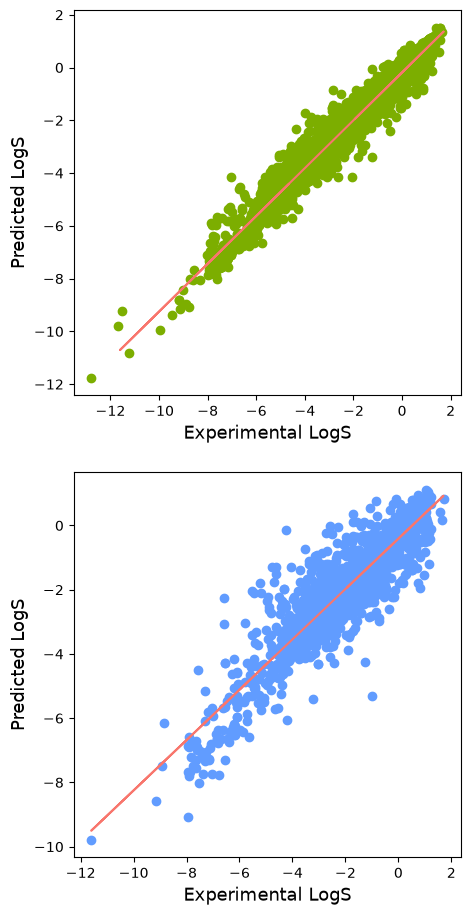

In [49]:
#Vertical plot
plt.figure(figsize=(5,11))

# 2 row, 1 column, plot 1
plt.subplot(2, 1, 1)
plt.scatter(x=Y_train, y=Y_pred_train, c="#7CAE00", alpha=1)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y_train, Y_pred_train, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")


plt.xlabel('Experimental LogS',fontsize=13)
plt.ylabel('Predicted LogS',fontsize=13)


# 2 row, 1 column, plot 2
plt.subplot(2, 1, 2)
plt.scatter(x=Y_test, y=Y_pred_test, c="#619CFF", alpha=1)

z = np.polyfit(Y_test, Y_pred_test, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.ylabel('Predicted LogS',fontsize=13)
plt.xlabel('Experimental LogS',fontsize=13)

# 出力
#plt.savefig('plot_vertical_logS.png')
#plt.savefig('output/paper logS morgan_ECFP_2048_RF.pdf',dpi=300)

plt.show()

### 3. SHAP計算

In [50]:
import shap
from sklearn.preprocessing import StandardScaler

In [51]:
%%time

X = X_test
Xscaler = StandardScaler()
X2= Xscaler.fit_transform(X)

explainer = shap.TreeExplainer(model,data=X2,
                               feature_perturbation='interventional'
                              )

shap_values = explainer.shap_values(X2)

Background dataset has 1688 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1688 when initializing the masker.
100%|===================| 1685/1688 [06:57<00:00]        

CPU times: total: 6min 32s
Wall time: 6min 59s


### beeswarm plot

**（図5）**

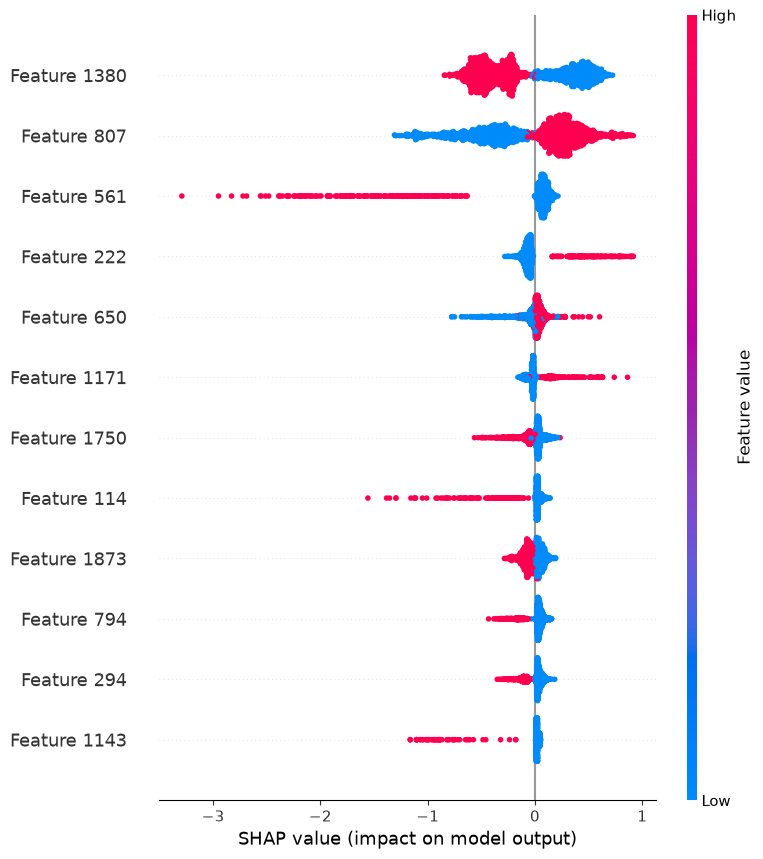

In [52]:
shap.summary_plot(shap_values, 
                  X2, 
                  plot_type="dot", 
                  plot_size=0.6, 
                  show=False,
                  max_display=12
                 )

### Global bar plot

**（図6）**

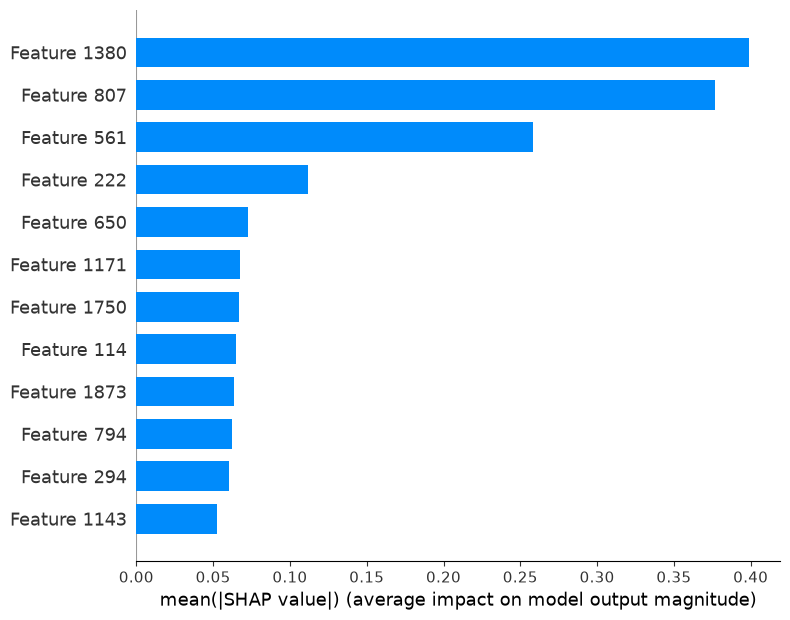

In [53]:
shap.summary_plot(shap_values, 
                  max_display=12, 
                  plot_type="bar",
                  show=False
                 )

### 係数の出力

In [54]:
vals = np.abs(shap_values).mean(0)

# 【修正】元のコードは col_name 列に X2[i]（1サンプル分の生の特徴量値）を入れていたため、
# 「col_name」という列名にもかかわらずビット番号ではなく無関係な数値が入っていた
# （ビット番号は結果的にDataFrameの行インデックスとしてしか表示されない状態だった）。
# ここでは各ビットの番号（0〜2047）を明示的にcol_name列として持たせる。
feature_importance = pd.DataFrame({'col_name': range(len(vals)), 'feature_importance_vals': vals})
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
feature_importance[:12]

,col_name,feature_importance_vals
1380,1380,0.399121
807,807,0.376663
561,561,0.258192
222,222,0.112043
650,650,0.072823
1171,1171,0.067425
1750,1750,0.066551
114,114,0.064916
1873,1873,0.063355
794,794,0.062023


In [55]:
feature_importance.to_excel(r'output/File Name44.xlsx', index = False)

### 4.ブラインドテスト・Solubility Challenge

`2_descriptor-paper2.ipynb`と同じく、学習に一切使用していない2つの外部検証データで予測します。

- **Blind test**（`testexperiment2upload3raw.csv`）: 炭素数1〜12・平均分子量190程度の低分子量有機化合物32件。
- **Solubility Challenge**（`testexperiment2upload2raw.csv`）: Llinàs et al. (2008) の "Solubility Challenge" セクションに掲載された医薬品類似化合物32件（平均分子量296）。

### Blind test（testexperiment2upload3raw.csv）

In [56]:
#Blind test
sol2 = pd.read_csv('data/testexperiment2upload3raw.csv')
sol2.head()

,Substance,SMILES
0,hexobarbital,CN1C(=O)NC(=O)C(C)(C1=O)C1=CCCCC1
1,nalidixic_acid,CCn1cc(c(=O)c2ccc(nc12)C)C(=O)O
2,phenantroline,c12c(ccc3cccnc13)cccn2
3,phenobarbital,C1(NC(C(c2ccccc2)(C(=O)N1)CC)=O)=O
4,sulfamethazine,S(=O)(=O)(Nc1nc(C)cc(n1)C)c1ccc(N)cc1


In [57]:
X3 = []
for smile in sol2['SMILES']:
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        continue
    X3.append(list(mfpgen.GetFingerprint(mol)))
print(len(X3))

32


In [58]:
Xnew=X3
ynew = model.predict(Xnew)
ynew

array([-2.370695  , -3.4094312 , -1.78729   , -2.34246771, -2.36204115,
       -3.92367856, -4.02035833, -2.17915   , -1.55641   , -2.8780243 ,
       -1.49360145, -2.24116667, -2.93051893, -2.87621   , -2.57178563,
       -1.1874825 , -3.40824498, -2.58238314, -2.2746    , -3.41979427,
       -0.99575283, -1.41459808, -2.78761587, -2.79663   , -2.18893333,
       -2.90352457, -1.7144001 , -1.981875  , -1.35115913, -4.15776667,
       -2.34441357, -2.28259875])

### Solubility Challenge（testexperiment2upload2raw.csv）

In [59]:
#Solubility Challenge
sol3 = pd.read_csv('data/testexperiment2upload2raw.csv')
sol3.head()

,name,SMILES
0,Acebutolol,CC(C)NCC(O)COC1=C(C(C)=O)C=C(NC(CCC)=O)C=C1
1,Amoxicillin,O=C(O)[C@H]1C(C)(C)S[C@@H](N21)[C@H](NC([C@@H]...
2,Bendroflumethiazide,O=S1(C2=CC(S(N)(=O)=O)=C(C(F)(F)F)C=C2NC(CC3=C...
3,Benzocaine,NC1=CC=C(C(OCC)=O)C=C1
4,Benzthiazide,O=S1(C2=CC(S(N)(=O)=O)=C(Cl)C=C2N=C(CSCC3=CC=C...


In [60]:
X4 = []
for smile in sol3['SMILES']:
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        continue
    X4.append(list(mfpgen.GetFingerprint(mol)))
print(len(X4))

32


In [61]:
X2new=X4
y2new = model.predict(X2new)
y2new

array([-2.51624833, -1.93963042, -2.50818   , -2.4391825 , -2.90084248,
       -1.12106667, -3.01201428, -2.48481659, -2.03662   , -2.27058844,
       -0.45147296, -0.99174   , -2.05579683, -3.67530845, -2.73524383,
       -2.07304917, -2.919     , -2.905393  , -1.80775   , -1.90400917,
       -1.73009728, -3.34922667, -0.99174   , -2.44684833, -3.80458   ,
       -1.40916   , -2.9132933 , -2.87859579, -1.71449923, -2.92980133,
       -3.20177   , -2.44125834])

### 予測値の出力保存

In [62]:
# define data
data = np.asarray(ynew)

# save to csv file
np.savetxt('output/data_ECFP.csv', data, delimiter=',')

### 可視化

**（図7：特定分子のMorganフィンガープリント部分構造の可視化）**

In [63]:
z = sol['SMILES']
z

0                 OCC1OC(CO)(OC2OC(CO)C(O)C(O)C2O)C(O)C1O
1       O[C@H]1[C@H](O[C@H](CO)[C@@H](O)[C@@H]1O)O[C@]...
2       OC[C@@H]1O[C@](CO)(O[C@@H]2O[C@@H](CO)[C@H](O)...
3                  CN1C[C@@H]2C[C@@H](C1)C3=CC=CC(=O)N3C2
4                            CN1CC2CC(C1)C1=CC=CC(=O)N1C2
                              ...                        
8433                                        O=[N+]([O-])C
8434                                                   OC
8435                                              S=C(N)N
8436                                             O=C(NO)N
8437                                              O=C(N)N
Name: SMILES, Length: 8438, dtype: str

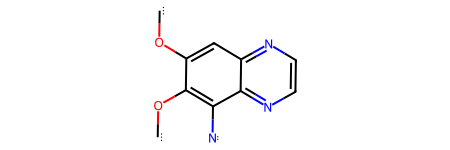

In [64]:
w = Chem.MolFromSmiles(z[1814])
w

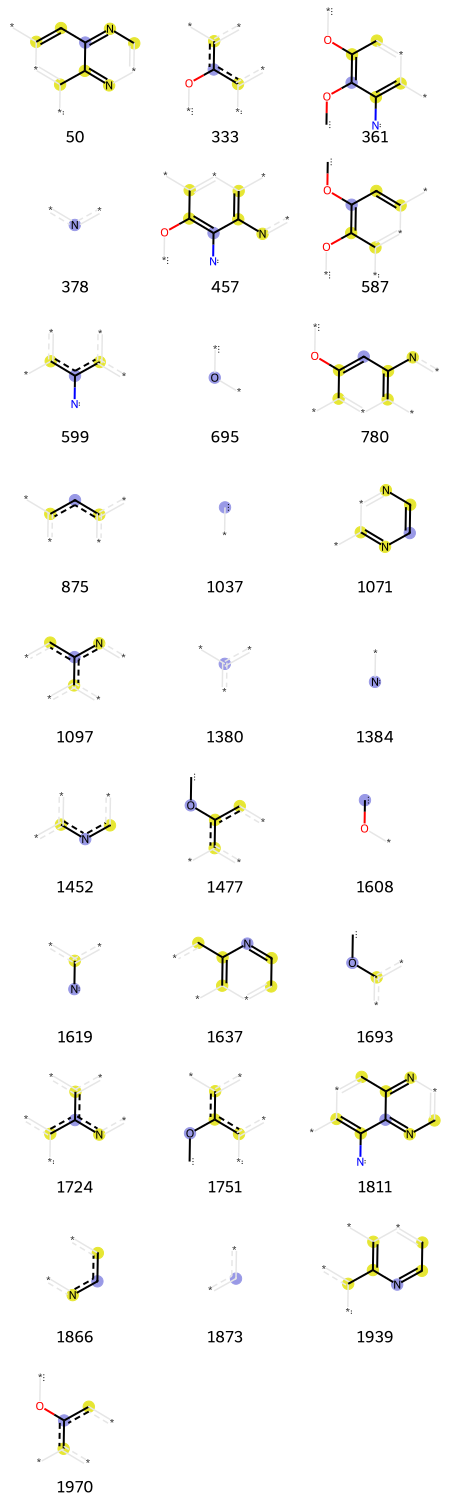

In [65]:
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()  # 各ビットがどの部分構造に対応するかの情報(bitInfo)を記録させる

fp = mfpgen.GetFingerprint(w, additionalOutput=ao)
bi = ao.GetBitInfoMap()

tpls = [(w,x,bi) for x in fp.GetOnBits()]

p = Draw.DrawMorganBits(tpls[:],
                        molsPerRow=3,
                        legends=[str(x) for x in fp.GetOnBits()][:]
                       )
p

### 【参考】 Figure2の作成

**（図8：原論文Figure 2相当の可視化）**

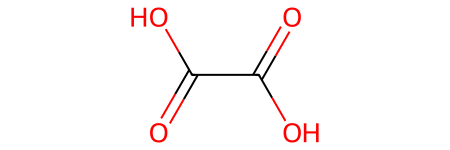

In [66]:
w = Chem.MolFromSmiles(z[8402])
w

In [67]:
ao_bz = rdFingerprintGenerator.AdditionalOutput()
ao_bz.AllocateBitInfoMap()

fp_bz = mfpgen.GetFingerprint(w, additionalOutput=ao_bz)
bi_bz = ao_bz.GetBitInfoMap()

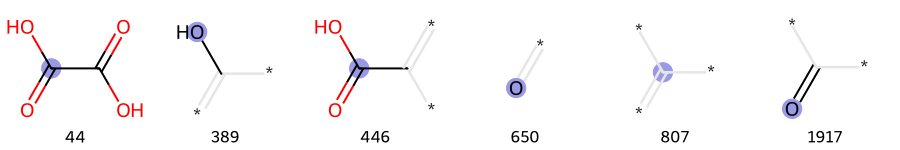

In [68]:
tpls = [(w,x,bi_bz) for x in fp_bz.GetOnBits()]

p = Draw.DrawMorganBits(tpls[:],
                        molsPerRow=6,
                        legends=[str(x) for x in fp_bz.GetOnBits()][:]
                       )
p

---
## ①モデル比較

Morganフィンガープリント（ECFP4相当）を説明変数として学習した4通りのモデルの性能を比較します。

| モデル | 特徴量 | 訓練 R² | 訓練 RMSE | 訓練 MAE | テスト R² | テスト RMSE | テスト MAE |
| --- | --- | --- | --- | --- | --- | --- | --- |
| MLR | 631ビット（LASSO刈り込み後） | 0.78 | 0.88 | 0.66 | 0.74 | 0.96 | 0.73 |
| RFR | 631ビット（LASSO刈り込み後） | 0.96 | 0.35 | 0.23 | 0.81 | 0.81 | 0.55 |
| MLR | 2048ビット（刈り込みなし） | 0.84 | 0.74 | 0.55 | 0.61 | 1.17 | 0.86 |
| RFR | 2048ビット（刈り込みなし） | 0.96 | 0.35 | 0.23 | 0.81 | 0.81 | 0.56 |

- **RFRはビット数に依存せず安定**しています（631ビットでも2048ビットでもテストR²は0.81でほぼ同じ）。決定木の分岐は個々のビットの有無だけを見るため、無関係なビットが混ざっていても性能への悪影響が小さいためと考えられます。
- **MLRはLASSOによる刈り込みで明確に改善**します（テストR²: 0.61→0.74）。2048ビットの生の特徴量は互いに強く相関するビットを多数含み、多重共線性により回帰係数の推定が不安定になりますが、LASSOで631ビットに絞ることでこの問題が緩和されます。この傾向は原論文（Tayyebi et al. 2023, Table 3）とも一致します。
- 全体として、RFRがMLRより高い予測精度を示す点は`2_descriptor-paper2.ipynb`（Mordred記述子モデル）と共通の傾向です。

## ②まとめ

- Morganフィンガープリント（半径2、2,048ビット）を`GetFingerprint()`（旧APIの`GetMorganFingerprintAsBitVect()`から移行）で生成し、LASSO回帰（alpha=0.001）による特徴量選択で631ビットに刈り込みました。
- MLR・RFRそれぞれについて、刈り込み前後（2048ビット／631ビット）の精度を比較し、モデルの種類によって刈り込みの効果が異なることを確認しました。
- SHAP解析により、Morganフィンガープリントの各ビット（部分構造）が溶解度予測に与える寄与を可視化しました。上位のビットには、原論文が指摘する「sp2炭素・水酸基・カルボキシル基・アミン基」に対応するビット（807・222・650・1171）が含まれており、化学的に妥当な結果が得られています。
- モデルが学習に一切使用していない2つの外部検証データ（Blind test・Solubility Challenge）に対する予測値も出力しました。
- コードレビューの過程で、Case2（2048ビット）MLRのテスト精度評価に変数の取り違えバグ（本来評価すべき`linearmodel`ではなく、別セクションのLASSOモデル`reg`を参照していた）を発見し修正しました。修正前は本来より良く見える決定係数（0.75）が表示されていましたが、これは`reg`が全データ（テストデータを含む）で学習されていたことによる見かけ上の精度であり、正しく評価するとテストR²は0.61でした。

## ③本編で扱っていないこと（今後の課題）

- LASSOによる特徴量選択は`train_test_split()`より前に全データへ適用しています。より厳密に行う場合は訓練データのみでLASSOを学習する方法も検討してください（本編中の該当セルに注記あり）。
- ハイパーパラメータ探索（LASSOのalpha値、RFRの木の数・深さの最適化）は行っていません。
- Blind test・Solubility Challengeの実測値との誤差評価（原論文ではMFモデルとMDモデルでそれぞれ0.64・1.12 logSの平均誤差と報告されています）。
- `2_descriptor-paper2.ipynb`で扱ったMordred物理化学的記述子モデルとの詳細な比較（本編はMorganフィンガープリントモデルのみを扱っています）。

## ④演習問題

1. LASSOのalpha値を0.0001や0.01に変更すると、刈り込み後のビット数（本編では631）とMLRのテストR²はどう変化するか確認してください。
2. Morganフィンガープリントの半径（`radius`パラメータ）を2から3に変更すると、予測精度はどう変わるか比較してください。
3. 図6（Global bar plot）で上位に挙がったビットについて、`Draw.DrawMorganBits()`を使ってどのような部分構造に対応するか可視化してください（図7・図8のコードが参考になります）。
